# 01 — Raw Data Profiling & Fidelity Audit

Scratch notebook — Q1-12 are pure code+output (analysis and conclusions
live in `docs/data_quality_report.md`). The Gates section (post-EDA) keeps
inline explanations since they're direct responses to an external review
and the numbers aren't self-interpretable without that context.

In [2]:
# Global imports
import duckdb
import polars as pl
import matplotlib.pyplot as plt

con = duckdb.connect("../data/claims.duckdb")

FIGURES_DIR = "../reports/figures"

## Question 1 — Row counts per table

Do the row counts in our loaded tables match the Data Users Document's
published Sample 1 figures?

In [3]:
expected = {
    "beneficiary": 343_644,  # 116,352 + 114,538 + 112,754 across 2008/2009/2010
    "inpatient": 66_773,
    "outpatient": 790_790,
    "pde": 5_552_421,
    "carrier": 4_741_335,
}

print(f"{'table':<15}{'actual':>12}{'expected':>12}{'match':>8}")
print("-" * 47)
for table, exp in expected.items():
    actual = con.execute(f"SELECT COUNT(*) FROM raw.{table}").fetchone()[0]
    match = "✓" if actual == exp else "✗"
    print(f"{table:<15}{actual:>12,}{exp:>12,}{match:>8}")

table                actual    expected   match
-----------------------------------------------
beneficiary         343,644     343,644       ✓
inpatient            66,773      66,773       ✓
outpatient          790,790     790,790       ✓
pde               5,552,421   5,552,421       ✓
carrier           4,741,335   4,741,335       ✓


## Question 2 — Distinct beneficiaries per year, and year-over-year overlap

This is the Sample 1 vs Sample 20 check (see `tests/test_sample_integrity.py`
for the automated version of this same check, which runs on every `make test`).

In [4]:
counts = {}
for year in [2008, 2009, 2010]:
    n = con.execute(f"""
        SELECT COUNT(DISTINCT DESYNPUF_ID)
        FROM raw.beneficiary
        WHERE source_year = {year}
    """).fetchone()[0]
    counts[year] = n
    print(f"{year}: {n:,} distinct beneficiaries")

overlap_08_10 = con.execute("""
    SELECT COUNT(*) FROM (
        SELECT DISTINCT DESYNPUF_ID FROM raw.beneficiary WHERE source_year = 2008
        INTERSECT
        SELECT DISTINCT DESYNPUF_ID FROM raw.beneficiary WHERE source_year = 2010
    )
""").fetchone()[0]

pct = 100 * overlap_08_10 / counts[2010]
print(f"\n2008 ∩ 2010 overlap: {overlap_08_10:,} ({pct:.1f}% of 2010's beneficiaries also in 2008)")

2008: 116,352 distinct beneficiaries
2009: 114,538 distinct beneficiaries
2010: 112,754 distinct beneficiaries

2008 ∩ 2010 overlap: 112,754 (100.0% of 2010's beneficiaries also in 2008)


## Question 3 — Orphan claims

Are there claims whose DESYNPUF_ID doesn't appear in any beneficiary file?
If so, what fraction — and does it matter for downstream joins?

In [5]:
claims_table = ["inpatient", "outpatient", "pde", "carrier"]
print(f"{'table':<12}{'total_rows':>12}{'orphan_rows':>14}{'orphan_pct':>12}")
print("-" * 50)
for table in claims_table:
    total = con.execute(f"SELECT COUNT(*) FROM raw.{table}").fetchone()[0]
    orphans = con.execute(f"""
        SELECT COUNT(*)
        FROM raw.{table} c
        LEFT JOIN (SELECT DISTINCT DESYNPUF_ID FROM raw.beneficiary) b
            on c.DESYNPUF_ID = b.DESYNPUF_ID
        WHERE b.DESYNPUF_ID IS NULL
    """).fetchone()[0]
    pct = 100 * orphans / total
    print(f"{table:<12}{total:>12,}{orphans:>14,}{pct:>11.2f}%")

table         total_rows   orphan_rows  orphan_pct
--------------------------------------------------
inpatient         66,773             0       0.00%
outpatient       790,790             0       0.00%
pde            5,552,421             0       0.00%
carrier        4,741,335             0       0.00%


## Question 4 — Date ranges per claims table

Min/max service dates per table. Dates are stored as YYYYMMDD integers but
loaded as VARCHAR (see Step 4) — cast to DATE here for range-checking.

In [6]:
date_cols = {
    "inpatient": "CLM_FROM_DT",
    "outpatient": "CLM_FROM_DT",
    "pde": "SRVC_DT",
    "carrier": "CLM_FROM_DT",
}

print(f"{'table':<12}{'min_date':>14}{'max_date':>14}{'out_of_range':>14}")
print("-" * 54)

for table, col in date_cols.items():
    result = con.execute(f"""
        SELECT
            CAST(MIN(STRPTIME({col}, '%Y%m%d')) AS DATE) AS min_dt,
            CAST(MAX(STRPTIME({col}, '%Y%m%d')) AS DATE) AS max_dt,
            SUM(CASE WHEN STRPTIME({col}, '%Y%m%d') < DATE '2008-01-01'
                    OR STRPTIME({col}, '%Y%m%d') > DATE '2010-12-31'
                THEN 1 ELSE 0 END) AS out_of_range
            FROM raw.{table}    
    """).fetchone()
    min_dt, max_dt, out_of_range = result
    print(f"{table:<12}{str(min_dt):>14}{str(max_dt):>14}{out_of_range:>14,}")

table             min_date      max_date  out_of_range
------------------------------------------------------
inpatient       2007-11-27    2010-12-30           224
outpatient      2007-12-12    2010-12-31           312
pde             2008-01-01    2010-12-31             0
carrier         2008-01-01    2010-12-31             0


In [7]:
for table, col in date_cols.items():
    if table in ("inpatient", "outpatient"):
        rows = con.execute(f"""
            SELECT CAST(STRPTIME({col}, '%Y%m%d') AS DATE) AS dt
            FROM raw.{table}
            WHERE STRPTIME({col}, '%Y%m%d') < DATE '2008-01-01'
               OR STRPTIME({col}, '%Y%m%d') > DATE '2010-12-31'
            ORDER BY dt
        """).fetchall()
        dates = [r[0] for r in rows]
        print(f"{table}: {len(dates)} out-of-range rows")
        print(f"  earliest: {dates[0]}, latest: {dates[-1]}")
        print(f"  first 5: {dates[:5]}")
        print(f"  last 5:  {dates[-5:]}\n")

inpatient: 224 out-of-range rows
  earliest: 2007-11-27, latest: 2007-12-31
  first 5: [datetime.date(2007, 11, 27), datetime.date(2007, 11, 28), datetime.date(2007, 12, 4), datetime.date(2007, 12, 5), datetime.date(2007, 12, 6)]
  last 5:  [datetime.date(2007, 12, 31), datetime.date(2007, 12, 31), datetime.date(2007, 12, 31), datetime.date(2007, 12, 31), datetime.date(2007, 12, 31)]

outpatient: 312 out-of-range rows
  earliest: 2007-12-12, latest: 2007-12-31
  first 5: [datetime.date(2007, 12, 12), datetime.date(2007, 12, 12), datetime.date(2007, 12, 12), datetime.date(2007, 12, 12), datetime.date(2007, 12, 12)]
  last 5:  [datetime.date(2007, 12, 31), datetime.date(2007, 12, 31), datetime.date(2007, 12, 31), datetime.date(2007, 12, 31), datetime.date(2007, 12, 31)]



## Question 5 — Monthly claim volume by table

Are there gaps, spikes, or a suspicious end-of-period drop-off? Right-censoring
at Dec 2010 matters heavily for persistence analysis in later weeks — this is
where we'd first see it.

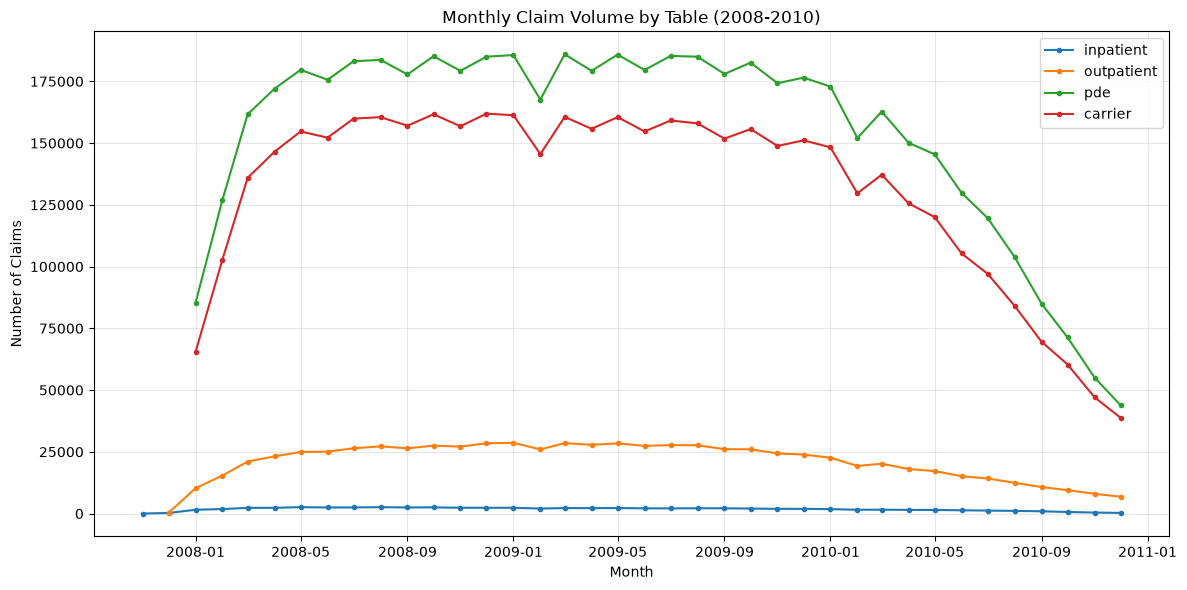

In [8]:
monthly_frames = []
for table, col in date_cols.items():
    df = con.execute(f"""
        SELECT 
            DATE_TRUNC('month',STRPTIME({col},'%Y%m%d')) AS month,
            COUNT(*) AS n_claims
        FROM raw.{table}
        GROUP BY month
        ORDER BY month
    """).pl()
    df = df.with_columns(pl.lit(table).alias("table"))
    monthly_frames.append(df)

monthly = pl.concat(monthly_frames)

fig, ax = plt.subplots(figsize=(12, 6))
for table in date_cols:
    sub = monthly.filter(pl.col("table") == table).sort("month")
    ax.plot(sub["month"], sub["n_claims"], marker="o", markersize=3, label=table)

ax.set_title("Monthly Claim Volume by Table (2008-2010)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Claims")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/monthly_claim_volume.png", dpi=150)
plt.show()

## Question 6 — Fills per beneficiary, 2008-2010

Median, 90th, and 99th percentile of total fills per beneficiary. What
fraction of beneficiaries have zero fills? (Zero-fill beneficiaries won't
appear in raw.pde at all, so this requires a LEFT JOIN against the full
beneficiary population, not just a count within PDE.)

In [20]:
fill_counts = con.execute("""
    SELECT
        b.DESYNPUF_ID,
        COUNT(p.PDE_ID) AS n_fills
    from (SELECT DISTINCT DESYNPUF_ID FROM raw.beneficiary) b
    LEFT JOIN raw.pde p ON b.DESYNPUF_ID = p.DESYNPUF_ID
    GROUP BY b.DESYNPUF_ID
""").pl()

n_total = fill_counts.height
n_zero = fill_counts.filter(pl.col("n_fills") == 0).height
pct_zero = 100 * n_zero / n_total

percentiles = (
    fill_counts["n_fills"].quantile(0.5),
    fill_counts["n_fills"].quantile(0.9),
    fill_counts["n_fills"].quantile(0.99),
)

print(f"Total beneficiaries: {n_total:,}")
print(f"Zero-fill beneficiaries: {n_zero:,} ({pct_zero:.1f}%)")
print(f"Median fills: {percentiles[0]:.0f}")
print(f"90th percentile: {percentiles[1]:.0f}")
print(f"99th percentile: {percentiles[2]:.0f}")

Total beneficiaries: 116,352
Zero-fill beneficiaries: 16,814 (14.5%)
Median fills: 26
90th percentile: 129
99th percentile: 198


## Question 7 — Days-supply distribution per fill

How dominant is 30-day supply? How common are 90-day fills? Anything
impossible — zero, negative, over 365? (CMS's own FAQ states zero
days-supply should be expected in this file — see docs notes from Step 2.)

In [21]:
days_supply = con.execute("""
    SELECT CAST(DAYS_SUPLY_NUM AS INTEGER) AS days_supply
    FROM raw.pde
""").pl()

print(days_supply["days_supply"].describe())

print("\nTop 10 most common days-supply values:")
print(days_supply.group_by("days_supply").len().sort("len", descending=True).head(10))

n_zero = days_supply.filter(pl.col("days_supply") == 0).height
n_negative = days_supply.filter(pl.col("days_supply") < 0).height
n_over_365 = days_supply.filter(pl.col("days_supply") > 365).height
n_total = days_supply.height

print(f"\nZero days-supply: {n_zero:,} ({100*n_zero/n_total:.2f}%)")
print(f"Negative days-supply: {n_negative:,} ({100*n_negative/n_total:.2f}%)")
print(f"Over 365 days-supply: {n_over_365:,} ({100*n_over_365/n_total:.2f}%)")

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 5.552421e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 34.181163  │
│ std        ┆ 21.24316   │
│ min        ┆ 0.0        │
│ 25%        ┆ 30.0       │
│ 50%        ┆ 30.0       │
│ 75%        ┆ 30.0       │
│ max        ┆ 90.0       │
└────────────┴────────────┘

Top 10 most common days-supply values:
shape: (10, 2)
┌─────────────┬─────────┐
│ days_supply ┆ len     │
│ ---         ┆ ---     │
│ i32         ┆ u32     │
╞═════════════╪═════════╡
│ 30          ┆ 3975996 │
│ 90          ┆ 596792  │
│ 10          ┆ 511597  │
│ 20          ┆ 232677  │
│ 0           ┆ 117726  │
│ 60          ┆ 55012   │
│ 50          ┆ 26452   │
│ 80          ┆ 22066   │
│ 40          ┆ 11609   │
│ 70          ┆ 2494    │
└─────────────┴─────────┘

Zero days-supply: 117,726 (2.12%)
Negative days-supply: 0 (0.00%)
Over 365 days-supply: 0 (0.0

## Question 8 — Product code structure

How many distinct product codes? What does the top-50 by fill count look
like? Are these real, mappable NDC-style codes, or has the synthesis
scrambled them? This determines how therapy classes get defined in Week 3.

In [22]:
n_distinct = con.execute("SELECT COUNT(DISTINCT PROD_SRVC_ID) FROM raw.pde").fetchone()[0]
print(f"Distinct product codes: {n_distinct:,}\n")

top_50 = con.execute("""
    SELECT PROD_SRVC_ID, COUNT(*) AS n_fills
    FROM raw.pde
    GROUP BY PROD_SRVC_ID
    ORDER BY n_fills DESC
    LIMIT 50
""").pl()

print(top_50)

Distinct product codes: 268,563

shape: (50, 2)
┌──────────────┬─────────┐
│ PROD_SRVC_ID ┆ n_fills │
│ ---          ┆ ---     │
│ str          ┆ i64     │
╞══════════════╪═════════╡
│ 00002840001  ┆ 206     │
│ 54868540600  ┆ 193     │
│ 64378033202  ┆ 187     │
│ 00065033230  ┆ 183     │
│ 54569489700  ┆ 182     │
│ …            ┆ …       │
│ 53978337003  ┆ 155     │
│ 62381840009  ┆ 155     │
│ 58016077728  ┆ 155     │
│ 54868548900  ┆ 154     │
│ 61947015803  ┆ 154     │
└──────────────┴─────────┘


In [23]:
labeler_codes = con.execute("""
    SELECT SUBSTRING(PROD_SRVC_ID, 1, 5) AS labeler_code, COUNT(*) AS n_fills
    FROM raw.pde
    GROUP BY labeler_code
    ORDER BY n_fills DESC
    LIMIT 20
""").pl()

print(labeler_codes)

shape: (20, 2)
┌──────────────┬─────────┐
│ labeler_code ┆ n_fills │
│ ---          ┆ ---     │
│ str          ┆ i64     │
╞══════════════╪═════════╡
│ 58016        ┆ 611243  │
│ 54868        ┆ 164072  │
│ 36987        ┆ 121940  │
│ 00247        ┆ 105153  │
│ 61392        ┆ 97719   │
│ …            ┆ …       │
│ 00615        ┆ 44902   │
│ 55045        ┆ 44403   │
│ 55289        ┆ 42970   │
│ 52959        ┆ 42053   │
│ 51079        ┆ 41432   │
└──────────────┴─────────┘


## Question 9 — Manual read of one beneficiary's fill sequence

Pick a high-volume product code, pull one beneficiary's fills for it, and
read the sequence by hand. Does the gap pattern between fills look like
plausible real refill behavior, or does it look like noise?

In [24]:
# Use the top labeler code's most common individual product, then find a
# beneficiary with several fills of it
top_product = con.execute("""
    SELECT PROD_SRVC_ID, COUNT(*) AS n_fills
    FROM raw.pde
    WHERE SUBSTRING(PROD_SRVC_ID, 1, 5) = '58016'
    GROUP BY PROD_SRVC_ID
    ORDER BY n_fills DESC
    LIMIT 1
""").fetchone()

product_id = top_product[0]
print(f"Using product code: {product_id} ({top_product[1]:,} total fills)\n")

candidate = con.execute(f"""
    SELECT DESYNPUF_ID, COUNT(*) AS n_fills
    FROM raw.pde
    WHERE PROD_SRVC_ID = '{product_id}'
    GROUP BY DESYNPUF_ID
    ORDER BY n_fills DESC
    LIMIT 1
""").fetchone()

bene_id = candidate[0]
print(f"Beneficiary with most fills of this product: {bene_id} ({candidate[1]} fills)\n")

sequence = con.execute(f"""
    SELECT
        CAST(STRPTIME(SRVC_DT, '%Y%m%d') AS DATE) AS fill_date,
        CAST(DAYS_SUPLY_NUM AS INTEGER) AS days_supply
    FROM raw.pde
    WHERE DESYNPUF_ID = '{bene_id}' AND PROD_SRVC_ID = '{product_id}'
    ORDER BY fill_date
""").pl()

sequence = sequence.with_columns(
    (pl.col("fill_date") - pl.col("fill_date").shift(1))
    .dt.total_days()
    .alias("days_since_last_fill")
)
print(sequence)

Using product code: 58016089232 (170 total fills)

Beneficiary with most fills of this product: 48C7C6BA209D1A3A (1 fills)

shape: (1, 3)
┌────────────┬─────────────┬──────────────────────┐
│ fill_date  ┆ days_supply ┆ days_since_last_fill │
│ ---        ┆ ---         ┆ ---                  │
│ date       ┆ i32         ┆ i64                  │
╞════════════╪═════════════╪══════════════════════╡
│ 2008-12-08 ┆ 90          ┆ null                 │
└────────────┴─────────────┴──────────────────────┘


In [25]:
top_labeler = "58016"

candidate = con.execute(f"""
    SELECT DESYNPUF_ID, COUNT(*) AS n_fills
    FROM raw.pde
    WHERE SUBSTRING(PROD_SRVC_ID, 1, 5) = '{top_labeler}'
    GROUP BY DESYNPUF_ID
    ORDER BY n_fills DESC
    LIMIT 1
""").fetchone()

bene_id = candidate[0]
print(f"Beneficiary with most fills from labeler {top_labeler}: {bene_id} ({candidate[1]} fills)\n")

sequence = con.execute(f"""
    SELECT
        PROD_SRVC_ID,
        CAST(STRPTIME(SRVC_DT, '%Y%m%d') AS DATE) AS fill_date,
        CAST(DAYS_SUPLY_NUM AS INTEGER) AS days_supply
    FROM raw.pde
    WHERE DESYNPUF_ID = '{bene_id}' AND SUBSTRING(PROD_SRVC_ID, 1, 5) = '{top_labeler}'
    ORDER BY fill_date
""").pl()

sequence = sequence.with_columns(
    (pl.col("fill_date") - pl.col("fill_date").shift(1))
    .dt.total_days()
    .alias("days_since_last_fill")
)

with pl.Config(tbl_rows=-1):
    print(sequence)

Beneficiary with most fills from labeler 58016: 288A5CA5F5683B03 (39 fills)

shape: (39, 4)
┌──────────────┬────────────┬─────────────┬──────────────────────┐
│ PROD_SRVC_ID ┆ fill_date  ┆ days_supply ┆ days_since_last_fill │
│ ---          ┆ ---        ┆ ---         ┆ ---                  │
│ str          ┆ date       ┆ i32         ┆ i64                  │
╞══════════════╪════════════╪═════════════╪══════════════════════╡
│ 58016042518  ┆ 2008-01-22 ┆ 30          ┆ null                 │
│ 58016066914  ┆ 2008-02-15 ┆ 30          ┆ 24                   │
│ 58016092204  ┆ 2008-03-15 ┆ 30          ┆ 29                   │
│ 58016005981  ┆ 2008-04-09 ┆ 30          ┆ 25                   │
│ 58016050626  ┆ 2008-04-24 ┆ 30          ┆ 15                   │
│ 58016059705  ┆ 2008-05-18 ┆ 90          ┆ 24                   │
│ 58016055708  ┆ 2008-06-28 ┆ 30          ┆ 41                   │
│ 58016045760  ┆ 2008-07-29 ┆ 30          ┆ 31                   │
│ 58016053718  ┆ 2008-08-04 ┆ 30     

## Question 10 — Demographics: age, sex, race, state; dual-eligible proportion

Compare against codebook-published Sample 1 figures. Note: DE-SynPUF's 32
beneficiary variables do not include a dual-eligible/Medicaid indicator, so
that portion of Q10 cannot be answered from this file — documented as a
limitation rather than approximated with a misleading proxy.

In [26]:
sex_dist = con.execute("""
    SELECT BENE_SEX_IDENT_CD, COUNT(*) AS n, 
           100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS pct
    FROM (SELECT DISTINCT DESYNPUF_ID, BENE_SEX_IDENT_CD FROM raw.beneficiary)
    GROUP BY BENE_SEX_IDENT_CD
""").pl()
print("Sex distribution:")
print(sex_dist)

race_dist = con.execute("""
    SELECT BENE_RACE_CD, COUNT(*) AS n,
           100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS pct
    FROM (SELECT DISTINCT DESYNPUF_ID, BENE_RACE_CD FROM raw.beneficiary)
    GROUP BY BENE_RACE_CD
    ORDER BY n DESC
""").pl()
print("\nRace distribution:")
print(race_dist)

Sex distribution:
shape: (2, 3)
┌───────────────────┬───────┬───────────┐
│ BENE_SEX_IDENT_CD ┆ n     ┆ pct       │
│ ---               ┆ ---   ┆ ---       │
│ str               ┆ i64   ┆ f64       │
╞═══════════════════╪═══════╪═══════════╡
│ 1                 ┆ 52005 ┆ 44.696267 │
│ 2                 ┆ 64347 ┆ 55.303733 │
└───────────────────┴───────┴───────────┘

Race distribution:
shape: (4, 3)
┌──────────────┬───────┬───────────┐
│ BENE_RACE_CD ┆ n     ┆ pct       │
│ ---          ┆ ---   ┆ ---       │
│ str          ┆ i64   ┆ f64       │
╞══════════════╪═══════╪═══════════╡
│ 1            ┆ 96349 ┆ 82.808203 │
│ 2            ┆ 12343 ┆ 10.608326 │
│ 3            ┆ 4931  ┆ 4.238002  │
│ 5            ┆ 2729  ┆ 2.345469  │
└──────────────┴───────┴───────────┘


In [27]:
age_dist = con.execute("""
    SELECT
        DATE_DIFF('year', CAST(STRPTIME(BENE_BIRTH_DT, '%Y%m%d') AS DATE), DATE '2008-01-01') AS age_2008,
        COUNT(*) AS n
    FROM (SELECT DISTINCT DESYNPUF_ID, BENE_BIRTH_DT FROM raw.beneficiary)
    GROUP BY age_2008
    ORDER BY age_2008
""").pl()

print(
    age_dist.select(
        pl.col("n").sum().alias("total"),
        (pl.col("age_2008") * pl.col("n")).sum().alias("weighted_sum"),
    ).with_columns((pl.col("weighted_sum") / pl.col("total")).alias("mean_age"))
)

print(f"\nMin age: {age_dist['age_2008'].min()}, Max age: {age_dist['age_2008'].max()}")
print("Median age (approx, via age_dist): computing below")

# Age buckets, matching the codebook's birth-year cohorts roughly
print("\nAge distribution (10-year buckets):")
buckets = (
    age_dist.with_columns((pl.col("age_2008") // 10 * 10).alias("age_bucket"))
    .group_by("age_bucket")
    .agg(pl.col("n").sum())
    .sort("age_bucket")
)
print(buckets)

state_dist = con.execute("""
    SELECT SP_STATE_CODE, COUNT(*) AS n
    FROM (SELECT DISTINCT DESYNPUF_ID, SP_STATE_CODE FROM raw.beneficiary)
    GROUP BY SP_STATE_CODE
    ORDER BY n DESC
    LIMIT 10
""").pl()
print("\nTop 10 states by beneficiary count:")
print(state_dist)

shape: (1, 3)
┌────────┬──────────────┬───────────┐
│ total  ┆ weighted_sum ┆ mean_age  │
│ ---    ┆ ---          ┆ ---       │
│ i64    ┆ i64          ┆ f64       │
╞════════╪══════════════╪═══════════╡
│ 116352 ┆ 8336297      ┆ 71.647217 │
└────────┴──────────────┴───────────┘

Min age: 25, Max age: 99
Median age (approx, via age_dist): computing below

Age distribution (10-year buckets):
shape: (8, 2)
┌────────────┬───────┐
│ age_bucket ┆ n     │
│ ---        ┆ ---   │
│ i64        ┆ i64   │
╞════════════╪═══════╡
│ 20         ┆ 785   │
│ 30         ┆ 2241  │
│ 40         ┆ 4478  │
│ 50         ┆ 7300  │
│ 60         ┆ 31899 │
│ 70         ┆ 40275 │
│ 80         ┆ 23750 │
│ 90         ┆ 5624  │
└────────────┴───────┘

Top 10 states by beneficiary count:
shape: (10, 2)
┌───────────────┬───────┐
│ SP_STATE_CODE ┆ n     │
│ ---           ┆ ---   │
│ str           ┆ i64   │
╞═══════════════╪═══════╡
│ 05            ┆ 10224 │
│ 10            ┆ 7745  │
│ 45            ┆ 6703  │
│ 33      

## Question 11 — Chronic condition prevalence vs. real Medicare

Recall polarity: code 1 = Yes, code 2 = No (see Step 2 codebook notes — NOT
0/1). Compare our loaded 2008 prevalence against codebook-published figures
and real-Medicare reference rates.

In [28]:
conditions = {
    "SP_ALZHDMTA": "Alzheimer's",
    "SP_CHF": "Heart Failure",
    "SP_CHRNKIDN": "Chronic Kidney Disease",
    "SP_CNCR": "Cancer",
    "SP_COPD": "COPD",
    "SP_DEPRESSN": "Depression",
    "SP_DIABETES": "Diabetes",
    "SP_ISCHMCHT": "Ischemic Heart Disease",
    "SP_OSTEOPRS": "Osteoporosis",
    "SP_RA_OA": "RA/Osteoarthritis",
    "SP_STRKETIA": "Stroke/TIA",
}

# Real Medicare reference rates, from Data Users Document Table 9 (Step 2 notes)
real_medicare_rates = {
    "Alzheimer's": 8,
    "Heart Failure": 12,
    "Chronic Kidney Disease": 9,
    "Cancer": None,  # not in Table 9's comparison set
    "COPD": 8,
    "Depression": 9,
    "Diabetes": 20,
    "Ischemic Heart Disease": 23,
    "Osteoporosis": 9,
    "RA/Osteoarthritis": 15,
    "Stroke/TIA": None,  # not in Table 9's comparison set
}

results = []
for col, label in conditions.items():
    pct_yes = con.execute(f"""
        SELECT 100.0 * SUM(CASE WHEN {col} = '1' THEN 1 ELSE 0 END) / COUNT(*)
        FROM (SELECT DISTINCT DESYNPUF_ID, {col} FROM raw.beneficiary WHERE source_year = 2008)
    """).fetchone()[0]
    results.append(
        {
            "condition": label,
            "our_2008_pct": pct_yes,
            "real_medicare_pct": real_medicare_rates[label],
        }
    )

prevalence = pl.DataFrame(results)
print(prevalence)

shape: (11, 3)
┌────────────────────────┬──────────────┬───────────────────┐
│ condition              ┆ our_2008_pct ┆ real_medicare_pct │
│ ---                    ┆ ---          ┆ ---               │
│ str                    ┆ f64          ┆ i64               │
╞════════════════════════╪══════════════╪═══════════════════╡
│ Alzheimer's            ┆ 19.26052     ┆ 8                 │
│ Heart Failure          ┆ 28.495428    ┆ 12                │
│ Chronic Kidney Disease ┆ 16.059887    ┆ 9                 │
│ Cancer                 ┆ 6.372903     ┆ null              │
│ COPD                   ┆ 13.530494    ┆ 8                 │
│ …                      ┆ …            ┆ …                 │
│ Diabetes               ┆ 37.867849    ┆ 20                │
│ Ischemic Heart Disease ┆ 42.063738    ┆ 23                │
│ Osteoporosis           ┆ 17.341344    ┆ 9                 │
│ RA/Osteoarthritis      ┆ 15.398102    ┆ 15                │
│ Stroke/TIA             ┆ 4.488965     ┆ null         

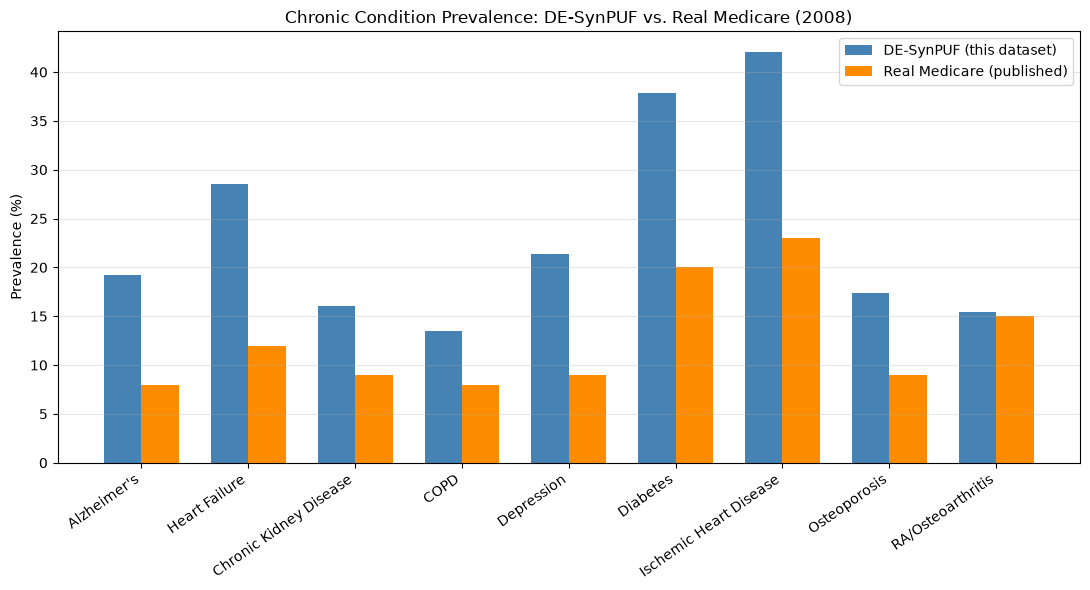

In [29]:
prevalence_clean = prevalence.filter(pl.col("real_medicare_pct").is_not_null())

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(prevalence_clean))
width = 0.35

ax.bar(
    [i - width / 2 for i in x],
    prevalence_clean["our_2008_pct"],
    width,
    label="DE-SynPUF (this dataset)",
    color="steelblue",
)
ax.bar(
    [i + width / 2 for i in x],
    prevalence_clean["real_medicare_pct"],
    width,
    label="Real Medicare (published)",
    color="darkorange",
)

ax.set_xticks(list(x))
ax.set_xticklabels(prevalence_clean["condition"], rotation=35, ha="right")
ax.set_ylabel("Prevalence (%)")
ax.set_title("Chronic Condition Prevalence: DE-SynPUF vs. Real Medicare (2008)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/chronic_condition_prevalence.png", dpi=150)
plt.show()

 ## Question 12 — Synthesis artifacts: three variable-pair associations

Runbook's suggested third pair (diabetes flag vs. antidiabetic drug fills)
is not answerable given Q8/Q9's finding that individual product codes don't
reliably map to real drug identities. Substituting: chronic condition count
vs. total annual reimbursement (both should track illness severity).

### Pair 1 — Age vs. chronic condition count

In [53]:
condition_cols = list(conditions.keys())
sum_expr = " + ".join([f"CASE WHEN {c} = '1' THEN 1 ELSE 0 END" for c in condition_cols])

age_vs_conditions = con.execute(f"""
    SELECT
        DATE_DIFF('year', CAST(STRPTIME(BENE_BIRTH_DT, '%Y%m%d') AS DATE), DATE '2008-01-01') AS age,
        ({sum_expr}) AS n_conditions
    FROM raw.beneficiary
    WHERE source_year = 2008
""").pl()

corr = age_vs_conditions.select(pl.corr("age", "n_conditions")).item()
print(f"Correlation (age, chronic condition count): {corr:.3f}")

avg_by_age_bucket = (
    age_vs_conditions.with_columns((pl.col("age") // 10 * 10).alias("age_bucket"))
    .group_by("age_bucket")
    .agg(pl.col("n_conditions").mean().alias("avg_conditions"))
    .sort("age_bucket")
)
print(avg_by_age_bucket)

Correlation (age, chronic condition count): 0.086
shape: (8, 2)
┌────────────┬────────────────┐
│ age_bucket ┆ avg_conditions │
│ ---        ┆ ---            │
│ i64        ┆ f64            │
╞════════════╪════════════════╡
│ 20         ┆ 1.973248       │
│ 30         ┆ 2.076305       │
│ 40         ┆ 2.229567       │
│ 50         ┆ 2.246986       │
│ 60         ┆ 1.783755       │
│ 70         ┆ 2.22987        │
│ 80         ┆ 2.674695       │
│ 90         ┆ 2.799787       │
└────────────┴────────────────┘


### Pair 1 — Correction and review

The original 0.086 correlation and the 60-69 dip were flagged as likely
misread. Real Medicare beneficiaries under 65 qualify via disability or
ESRD, making them systematically sicker than people who "aged in" normally
at 65: a U-shape is expected real structure, not synthesis damage, which was 
my earlier inference.
So now, recomputing on 65+ only, using Spearman (better suited to non-monotonic
relationships than Pearson).

In [54]:
age_65plus = age_vs_conditions.filter(pl.col("age") >= 65)

spearman_65plus = age_65plus.select(pl.corr("age", "n_conditions", method="spearman")).item()
print(f"Spearman correlation (age, chronic conditions), 65+ only: {spearman_65plus:.3f}")

avg_by_age_65plus = (
    age_65plus.with_columns((pl.col("age") // 10 * 10).alias("age_bucket"))
    .group_by("age_bucket")
    .agg(pl.col("n_conditions").mean().alias("avg_conditions"))
    .sort("age_bucket")
)
print(avg_by_age_65plus)

Spearman correlation (age, chronic conditions), 65+ only: 0.159
shape: (4, 2)
┌────────────┬────────────────┐
│ age_bucket ┆ avg_conditions │
│ ---        ┆ ---            │
│ i64        ┆ f64            │
╞════════════╪════════════════╡
│ 60         ┆ 1.704528       │
│ 70         ┆ 2.22987        │
│ 80         ┆ 2.674695       │
│ 90         ┆ 2.799787       │
└────────────┴────────────────┘


In [55]:
print(f"Min age in filtered data: {age_65plus['age'].min()}")
print(f"Max age in filtered data: {age_65plus['age'].max()}")
print(f"Beneficiaries in 65+ filter: {age_65plus.height:,}")

Min age in filtered data: 65
Max age in filtered data: 99
Beneficiaries in 65+ filter: 97,232


### Pair 2 — inpatient admissions and total reimbursement.

In [56]:
admits_vs_reimb = con.execute("""
    SELECT
        b.DESYNPUF_ID,
        COUNT(i.CLM_ID) AS n_admissions,
        MAX(TRY_CAST(b.MEDREIMB_IP AS DOUBLE)) AS total_ip_reimb
    FROM raw.beneficiary b
    LEFT JOIN raw.inpatient i ON b.DESYNPUF_ID = i.DESYNPUF_ID
    WHERE b.source_year = 2008
    GROUP BY b.DESYNPUF_ID
""").pl()

corr2 = admits_vs_reimb.select(pl.corr("n_admissions", "total_ip_reimb")).item()
print(f"Correlation (inpatient admissions, total IP reimbursement): {corr2:.3f}")

avg_reimb_by_admits = (
    admits_vs_reimb.group_by("n_admissions")
    .agg(pl.col("total_ip_reimb").mean().alias("avg_reimb"), pl.len().alias("n_beneficiaries"))
    .sort("n_admissions")
)
print(avg_reimb_by_admits.head(8))

Correlation (inpatient admissions, total IP reimbursement): 0.643
shape: (8, 3)
┌──────────────┬──────────────┬─────────────────┐
│ n_admissions ┆ avg_reimb    ┆ n_beneficiaries │
│ ---          ┆ ---          ┆ ---             │
│ i64          ┆ f64          ┆ u32             │
╞══════════════╪══════════════╪═════════════════╡
│ 0            ┆ 0.0          ┆ 78572           │
│ 1            ┆ 1994.710773  ┆ 22612           │
│ 2            ┆ 7620.942892  ┆ 8230            │
│ 3            ┆ 15255.128205 ┆ 3432            │
│ 4            ┆ 21855.939675 ┆ 1724            │
│ 5            ┆ 28299.720358 ┆ 894             │
│ 6            ┆ 35998.189474 ┆ 475             │
│ 7            ┆ 37554.050633 ┆ 237             │
└──────────────┴──────────────┴─────────────────┘


### Pair 2 — Correction and review

Original query had a time-window mismatch: counted inpatient admissions
across all 3 years but joined to 2008-only reimbursement, so anyone whose
single admission fell in 2009/2010 incorrectly showed $0. Restricting
admissions to 2008 dates only, matching the reimbursement year.

In [57]:
admits_vs_reimb_fixed = con.execute("""
    SELECT
        b.DESYNPUF_ID,
        COUNT(i.CLM_ID) AS n_admissions_2008,
        MAX(TRY_CAST(b.MEDREIMB_IP AS DOUBLE)) AS total_ip_reimb
    FROM raw.beneficiary b
    LEFT JOIN raw.inpatient i ON b.DESYNPUF_ID = i.DESYNPUF_ID
        AND STRPTIME(i.CLM_FROM_DT, '%Y%m%d') < DATE '2009-01-01'
    WHERE b.source_year = 2008
    GROUP BY b.DESYNPUF_ID
""").pl()

corr2_fixed = admits_vs_reimb_fixed.select(pl.corr("n_admissions_2008", "total_ip_reimb")).item()
print(f"Corrected correlation (2008 admissions, 2008 IP reimbursement): {corr2_fixed:.3f}")

avg_reimb_fixed = (
    admits_vs_reimb_fixed.group_by("n_admissions_2008")
    .agg(pl.col("total_ip_reimb").mean().alias("avg_reimb"), pl.len().alias("n_beneficiaries"))
    .sort("n_admissions_2008")
)
print(avg_reimb_fixed.head(8))

Corrected correlation (2008 admissions, 2008 IP reimbursement): 0.828
shape: (8, 3)
┌───────────────────┬──────────────┬─────────────────┐
│ n_admissions_2008 ┆ avg_reimb    ┆ n_beneficiaries │
│ ---               ┆ ---          ┆ ---             │
│ i64               ┆ f64          ┆ u32             │
╞═══════════════════╪══════════════╪═════════════════╡
│ 0                 ┆ 0.0          ┆ 100423          │
│ 1                 ┆ 8502.997413  ┆ 8891            │
│ 2                 ┆ 18058.149693 ┆ 4075            │
│ 3                 ┆ 28989.21445  ┆ 1744            │
│ 4                 ┆ 40539.741144 ┆ 734             │
│ 5                 ┆ 50780.0      ┆ 308             │
│ 6                 ┆ 64303.87931  ┆ 116             │
│ 7                 ┆ 77268.75     ┆ 40              │
└───────────────────┴──────────────┴─────────────────┘


### Pair 3 — chronic condition count and total annual reimbursement

In [40]:
condition_cols = list(conditions.keys())
sum_expr = " + ".join([f"CASE WHEN {c} = '1' THEN 1 ELSE 0 END" for c in condition_cols])

conditions_vs_total_reimb = con.execute(f"""
    SELECT
        ({sum_expr}) AS n_conditions,
        TRY_CAST(MEDREIMB_IP AS DOUBLE) + TRY_CAST(MEDREIMB_OP AS DOUBLE) + TRY_CAST(MEDREIMB_CAR AS DOUBLE) AS total_reimb
    FROM raw.beneficiary
    WHERE source_year = 2008
""").pl()

corr3 = conditions_vs_total_reimb.select(pl.corr("n_conditions", "total_reimb")).item()
print(f"Correlation (chronic condition count, total annual reimbursement): {corr3:.3f}")

avg_by_condition_count = (
    conditions_vs_total_reimb.group_by("n_conditions")
    .agg(pl.col("total_reimb").mean().alias("avg_total_reimb"), pl.len().alias("n_beneficiaries"))
    .sort("n_conditions")
)
print(avg_by_condition_count)

Correlation (chronic condition count, total annual reimbursement): 0.553
shape: (12, 3)
┌──────────────┬─────────────────┬─────────────────┐
│ n_conditions ┆ avg_total_reimb ┆ n_beneficiaries │
│ ---          ┆ ---             ┆ ---             │
│ i32          ┆ f64             ┆ u32             │
╞══════════════╪═════════════════╪═════════════════╡
│ 0            ┆ 207.750072      ┆ 45077           │
│ 1            ┆ 1399.206641     ┆ 13613           │
│ 2            ┆ 2247.80049      ┆ 13062           │
│ 3            ┆ 3318.592599     ┆ 11674           │
│ 4            ┆ 5161.866614     ┆ 10061           │
│ …            ┆ …               ┆ …               │
│ 7            ┆ 16799.963303    ┆ 4360            │
│ 8            ┆ 22401.690141    ┆ 2556            │
│ 9            ┆ 28601.270962    ┆ 1133            │
│ 10           ┆ 35762.369146    ┆ 363             │
│ 11           ┆ 43189.565217    ┆ 46              │
└──────────────┴─────────────────┴─────────────────┘


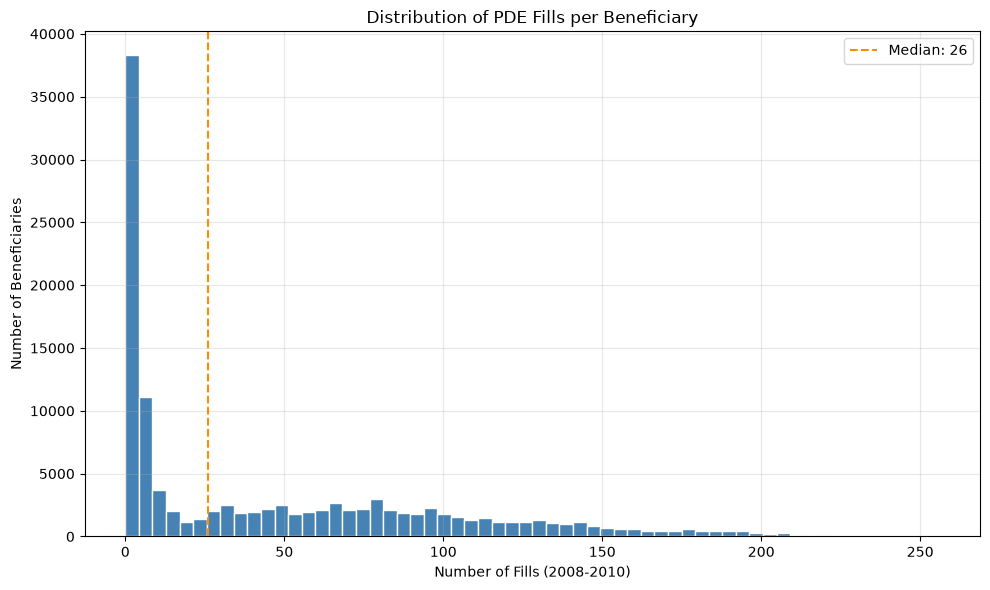

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(fill_counts["n_fills"], bins=60, color="steelblue", edgecolor="white")
ax.axvline(
    fill_counts["n_fills"].median(),
    color="darkorange",
    linestyle="--",
    label=f"Median: {fill_counts['n_fills'].median():.0f}",
)
ax.set_xlabel("Number of Fills (2008-2010)")
ax.set_ylabel("Number of Beneficiaries")
ax.set_title("Distribution of PDE Fills per Beneficiary")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fills_per_beneficiary_histogram.png", dpi=150)
plt.show()

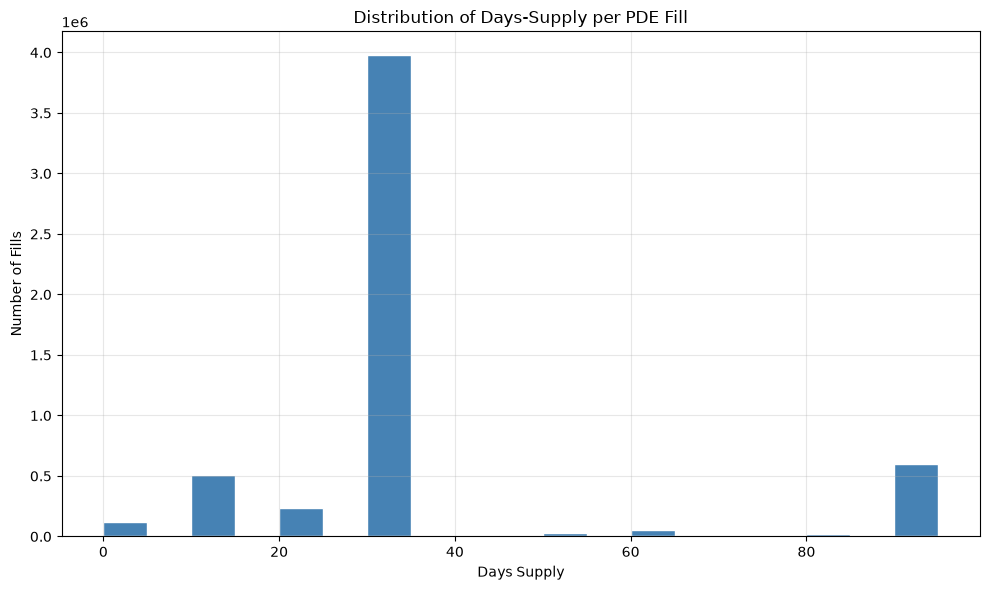

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(days_supply["days_supply"], bins=range(0, 100, 5), color="steelblue", edgecolor="white")
ax.set_xlabel("Days Supply")
ax.set_ylabel("Number of Fills")
ax.set_title("Distribution of Days-Supply per PDE Fill")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/days_supply_histogram.png", dpi=150)
plt.show()

---

# Post-EDA Validation Gates

The findings above were reviewed externally (strategy discussion) before
writing the final report. That review corrected two interpretation errors
(Q12 Pairs 1 and 2) and flagged that the Q9 finding: one beneficiary's
fill sequence showing zero repeated product codes, needed population-wide
confirmation before being treated as a general property of the file. The
five gates below do that confirmation, and their results directly determine
the final Constraints section and several Week 3+ design decisions.

## Gate 1 — Population-wide refill-pair check

Does the Q9 finding (39 fills, 39 different product codes, zero repeats)
hold across the whole file, or was that one beneficiary unusual? Checking
at both individual PROD_SRVC_ID level and 5-digit labeler level.

In [43]:
# Individual product code level
product_pairs = con.execute("""
    SELECT COUNT(*) AS pairs, SUM(CASE WHEN n >= 2 THEN 1 ELSE 0 END) AS pairs_with_refill
    FROM (
        SELECT DESYNPUF_ID, PROD_SRVC_ID, COUNT(*) AS n
        FROM raw.pde
        GROUP BY DESYNPUF_ID, PROD_SRVC_ID
    )
""").fetchone()

pct_refill_product = 100 * product_pairs[1] / product_pairs[0]
print("Product-code level:")
print(f"  Total (beneficiary, product) pairs: {product_pairs[0]:,}")
print(f"  Pairs with >=2 fills (a real refill): {product_pairs[1]:,} ({pct_refill_product:.2f}%)")

# Labeler code level
labeler_pairs = con.execute("""
    SELECT COUNT(*) AS pairs, SUM(CASE WHEN n >= 2 THEN 1 ELSE 0 END) AS pairs_with_refill
    FROM (
        SELECT DESYNPUF_ID, SUBSTRING(PROD_SRVC_ID, 1, 5) AS labeler, COUNT(*) AS n
        FROM raw.pde
        GROUP BY DESYNPUF_ID, labeler
    )
""").fetchone()

pct_refill_labeler = 100 * labeler_pairs[1] / labeler_pairs[0]
print("\nLabeler-code level:")
print(f"  Total (beneficiary, labeler) pairs: {labeler_pairs[0]:,}")
print(f"  Pairs with >=2 fills: {labeler_pairs[1]:,} ({pct_refill_labeler:.2f}%)")

Product-code level:
  Total (beneficiary, product) pairs: 5,549,151
  Pairs with >=2 fills (a real refill): 3,263 (0.06%)

Labeler-code level:
  Total (beneficiary, labeler) pairs: 4,037,386
  Pairs with >=2 fills: 717,647 (17.78%)


## Gate 2 — Labeler concentration within a person, vs. a shuffle null

For each beneficiary, compute the share of their fills coming from their
single most-common labeler. Then randomly permute the labeler column across
ALL fills (destroying any real person-labeler association) and recompute
the same statistic. If real and shuffled distributions look similar, labeler
carries no real person-level signal. It's effectively assigned per-claim,
not per-person.

In [44]:
pde_labelers = con.execute("""
    SELECT DESYNPUF_ID, SUBSTRING(PROD_SRVC_ID, 1, 5) AS labeler
    FROM raw.pde
""").pl()

real_concentration = (
    pde_labelers.group_by(["DESYNPUF_ID", "labeler"])
    .len()
    .group_by("DESYNPUF_ID")
    .agg(
        [
            pl.col("len").max().alias("top_labeler_fills"),
            pl.col("len").sum().alias("total_fills"),
        ]
    )
    .with_columns((pl.col("top_labeler_fills") / pl.col("total_fills")).alias("top_labeler_share"))
)

print("Real data — top-labeler share per beneficiary:")
print(real_concentration["top_labeler_share"].describe())

Real data — top-labeler share per beneficiary:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 99538.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.216186 │
│ std        ┆ 0.219088 │
│ min        ┆ 0.022222 │
│ 25%        ┆ 0.1      │
│ 50%        ┆ 0.133333 │
│ 75%        ┆ 0.230769 │
│ max        ┆ 1.0      │
└────────────┴──────────┘


In [45]:
import numpy as np

np.random.seed(7)  # same seed convention as build_fixture.py, for consistency

shuffled_labelers = pde_labelers.with_columns(pl.col("labeler").shuffle(seed=7).alias("labeler"))

shuffled_concentration = (
    shuffled_labelers.group_by(["DESYNPUF_ID", "labeler"])
    .len()
    .group_by("DESYNPUF_ID")
    .agg(
        [
            pl.col("len").max().alias("top_labeler_fills"),
            pl.col("len").sum().alias("total_fills"),
        ]
    )
    .with_columns((pl.col("top_labeler_fills") / pl.col("total_fills")).alias("top_labeler_share"))
)

print("Shuffled null — top-labeler share per beneficiary:")
print(shuffled_concentration["top_labeler_share"].describe())

Shuffled null — top-labeler share per beneficiary:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 99538.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.215759 │
│ std        ┆ 0.219103 │
│ min        ┆ 0.017544 │
│ 25%        ┆ 0.1      │
│ 50%        ┆ 0.132653 │
│ 75%        ┆ 0.230769 │
│ max        ┆ 1.0      │
└────────────┴──────────┘


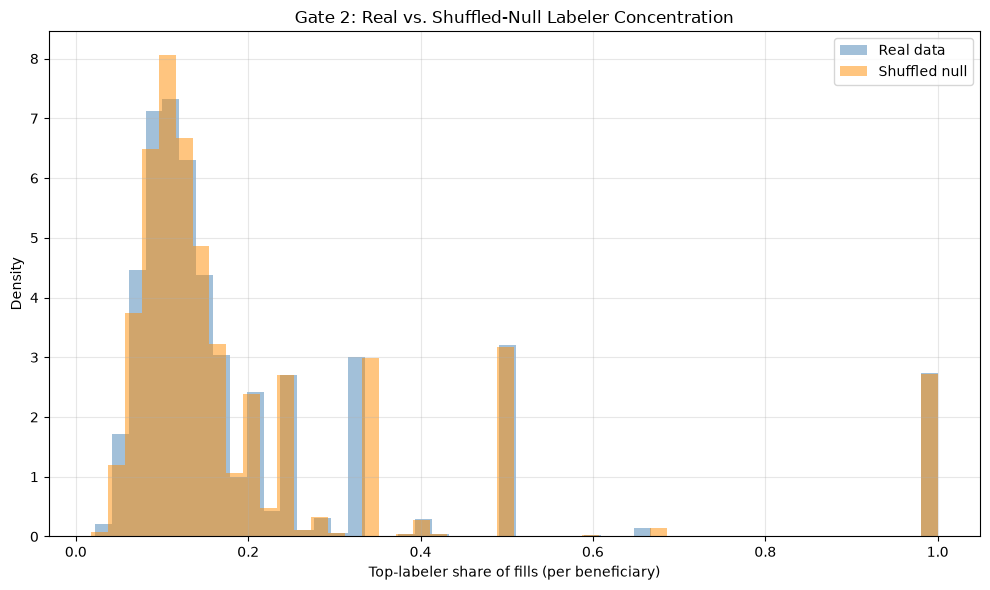

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    real_concentration["top_labeler_share"],
    bins=50,
    alpha=0.5,
    label="Real data",
    color="steelblue",
    density=True,
)
ax.hist(
    shuffled_concentration["top_labeler_share"],
    bins=50,
    alpha=0.5,
    label="Shuffled null",
    color="darkorange",
    density=True,
)
ax.set_xlabel("Top-labeler share of fills (per beneficiary)")
ax.set_ylabel("Density")
ax.set_title("Gate 2: Real vs. Shuffled-Null Labeler Concentration")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/gate2_labeler_concentration_null_test.png", dpi=150)
plt.show()

## Gate 3 — 90-day fill share within a person, vs. a shuffle null

Same technique as Gate 2, applied to a different variable: for each
beneficiary, what share of their fills are 90-day supply? Compared against
a shuffled null where the 90-day/not-90-day label is randomly reassigned
across all fills, breaking any real person-level association.

This is the most consequential gate — it directly determines whether
"90-day vs. 30-day supply at initiation" is a real, stable enough personal
trait to support Module C's proposed active-comparator redesign, or whether that comparator needs to be abandoned too, following the same fate as the original drug-class design.

In [47]:
pde_days_supply = con.execute("""
    SELECT DESYNPUF_ID, CAST(DAYS_SUPLY_NUM AS INTEGER) AS days_supply
    FROM raw.pde
""").pl()

pde_days_supply = pde_days_supply.with_columns((pl.col("days_supply") == 90).alias("is_90day"))

real_90day_share = (
    pde_days_supply.group_by("DESYNPUF_ID")
    .agg(
        [
            pl.col("is_90day").sum().alias("n_90day"),
            pl.len().alias("total_fills"),
        ]
    )
    .with_columns((pl.col("n_90day") / pl.col("total_fills")).alias("share_90day"))
)

print("Real data — 90-day fill share per beneficiary:")
print(real_90day_share["share_90day"].describe())

shuffled_is_90day = pde_days_supply.with_columns(
    pl.col("is_90day").shuffle(seed=7).alias("is_90day")
)

shuffled_90day_share = (
    shuffled_is_90day.group_by("DESYNPUF_ID")
    .agg(
        [
            pl.col("is_90day").sum().alias("n_90day"),
            pl.len().alias("total_fills"),
        ]
    )
    .with_columns((pl.col("n_90day") / pl.col("total_fills")).alias("share_90day"))
)

print("\nShuffled null — 90-day fill share per beneficiary:")
print(shuffled_90day_share["share_90day"].describe())

Real data — 90-day fill share per beneficiary:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 99538.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.1162   │
│ std        ┆ 0.129808 │
│ min        ┆ 0.0      │
│ 25%        ┆ 0.04     │
│ 50%        ┆ 0.1      │
│ 75%        ┆ 0.144578 │
│ max        ┆ 1.0      │
└────────────┴──────────┘

Shuffled null — 90-day fill share per beneficiary:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 99538.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.107335 │
│ std        ┆ 0.118053 │
│ min        ┆ 0.0      │
│ 25%        ┆ 0.034483 │
│ 50%        ┆ 0.097938 │
│ 75%        ┆ 0.134328 │
│ max        ┆ 1.0      │
└────────────┴──────────┘


KS statistic: 0.0510
p-value: 4.22e-113


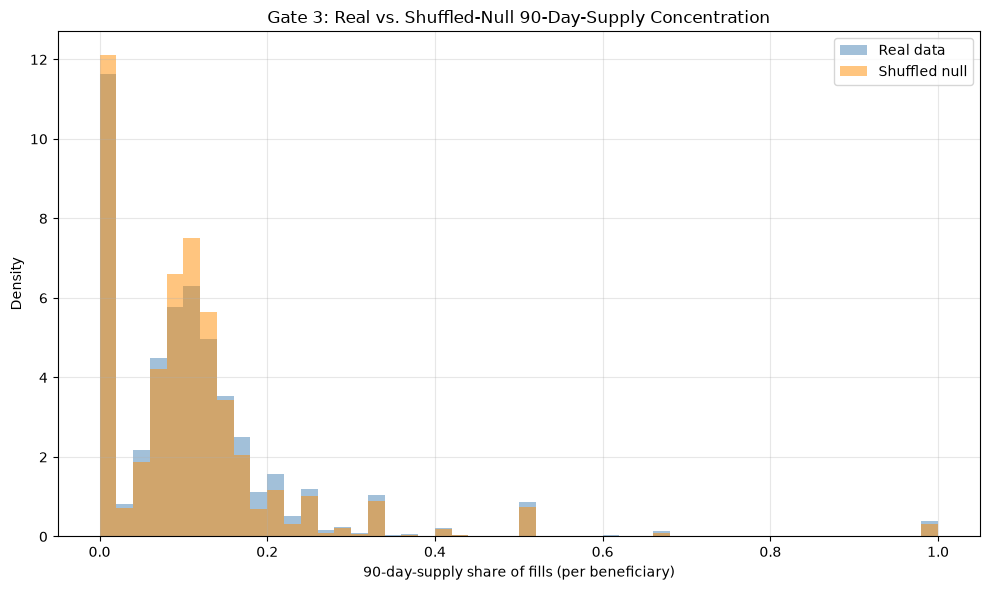

In [48]:
from scipy import stats

ks_stat, ks_pvalue = stats.ks_2samp(
    real_90day_share["share_90day"].to_numpy(), shuffled_90day_share["share_90day"].to_numpy()
)

print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_pvalue:.2e}")

# Also plot, same style as Gate 2
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    real_90day_share["share_90day"],
    bins=50,
    alpha=0.5,
    label="Real data",
    color="steelblue",
    density=True,
)
ax.hist(
    shuffled_90day_share["share_90day"],
    bins=50,
    alpha=0.5,
    label="Shuffled null",
    color="darkorange",
    density=True,
)
ax.set_xlabel("90-day-supply share of fills (per beneficiary)")
ax.set_ylabel("Density")
ax.set_title("Gate 3: Real vs. Shuffled-Null 90-Day-Supply Concentration")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/gate3_90day_share_null_test.png", dpi=150)
plt.show()

## Gate 4 — Fills per enrolled beneficiary by month

Q5 showed raw monthly claim volume dropping ~70-80% by late 2010, and the
strategy review flagged that "claims lag" doesn't fit that shape (lag
concentrates in the final few months; this decline starts in January 2010
and deepens for eleven straight months). The review also noted the
beneficiary population itself only shrinks ~3% year-over-year — so most of
the raw decline must be a drop in fills *per person*, not fewer people.

This gate normalizes by the actual enrolled population each month, to find
where per-person volume first drops below ~90% of the 2009 plateau level —
that point becomes the last usable outcome date for any persistence/
adherence analysis in later weeks.

In [49]:
# Enrolled beneficiaries per month: a beneficiary is "enrolled" in a given
# month if that month falls within their source_year (crude but adequate
# for a monthly denominator — refined coverage-month logic belongs in Week 3)
monthly_fills = con.execute("""
    SELECT DATE_TRUNC('month', STRPTIME(SRVC_DT, '%Y%m%d')) AS month,
           COUNT(*) AS n_fills,
           COUNT(DISTINCT DESYNPUF_ID) AS n_distinct_fillers
    FROM raw.pde
    GROUP BY month
    ORDER BY month
""").pl()

# Enrolled population per year (proxy: distinct beneficiaries in that source_year)
enrolled_per_year = con.execute("""
    SELECT source_year, COUNT(DISTINCT DESYNPUF_ID) AS n_enrolled
    FROM raw.beneficiary
    GROUP BY source_year
""").pl()
print("Enrolled beneficiaries per year:")
print(enrolled_per_year)

monthly_fills = monthly_fills.with_columns(pl.col("month").dt.year().alias("year"))
monthly_fills = monthly_fills.join(enrolled_per_year, left_on="year", right_on="source_year")
monthly_fills = monthly_fills.with_columns(
    (pl.col("n_fills") / pl.col("n_enrolled")).alias("fills_per_enrolled")
)

print("\nFills per enrolled beneficiary, by month:")
with pl.Config(tbl_rows=-1):
    print(monthly_fills.select(["month", "n_fills", "n_enrolled", "fills_per_enrolled"]))

# 2009 plateau baseline: mean fills-per-enrolled across 2009 months
plateau_2009 = monthly_fills.filter(pl.col("year") == 2009)["fills_per_enrolled"].mean()
threshold = 0.90 * plateau_2009
print(f"\n2009 plateau (mean fills/enrolled): {plateau_2009:.3f}")
print(f"90% threshold: {threshold:.3f}")

below_threshold = monthly_fills.filter(
    (pl.col("year") == 2010) & (pl.col("fills_per_enrolled") < threshold)
).sort("month")
print("\nFirst 2010 month below 90% of 2009 plateau:")
print(below_threshold.head(1).select(["month", "fills_per_enrolled"]))

Enrolled beneficiaries per year:
shape: (3, 2)
┌─────────────┬────────────┐
│ source_year ┆ n_enrolled │
│ ---         ┆ ---        │
│ i32         ┆ i64        │
╞═════════════╪════════════╡
│ 2008        ┆ 116352     │
│ 2010        ┆ 112754     │
│ 2009        ┆ 114538     │
└─────────────┴────────────┘

Fills per enrolled beneficiary, by month:
shape: (36, 4)
┌─────────────────────┬─────────┬────────────┬────────────────────┐
│ month               ┆ n_fills ┆ n_enrolled ┆ fills_per_enrolled │
│ ---                 ┆ ---     ┆ ---        ┆ ---                │
│ datetime[μs]        ┆ i64     ┆ i64        ┆ f64                │
╞═════════════════════╪═════════╪════════════╪════════════════════╡
│ 2008-01-01 00:00:00 ┆ 85200   ┆ 116352     ┆ 0.732261           │
│ 2008-02-01 00:00:00 ┆ 127033  ┆ 116352     ┆ 1.091799           │
│ 2008-03-01 00:00:00 ┆ 161641  ┆ 116352     ┆ 1.389241           │
│ 2008-04-01 00:00:00 ┆ 172025  ┆ 116352     ┆ 1.478488           │
│ 2008-05-01 00:00:00 

### Gate 5 — Wording correction 

The original conclusion overstated what a "no results" FDA NDC Directory
search proves. The directory only lists **currently marketed** products —
a labeler code absent today doesn't prove it was synthesized in 2008; it
could simply belong to a company that stopped operating or was acquired in
the intervening ~18 years.

**The FDA lookup alone is suggestive, not conclusive.** The stronger,
already-established evidence that these top labeler codes carry no
trustworthy signal is Gate 2: real vs. shuffled-null distributions of
labeler concentration were statistically indistinguishable, and one
labeler code accounting for 11% of all 5.5M fills file-wide is itself
implausible for a single real-world manufacturer at that market share.
Gate 5's directory lookup is a supporting, illustrative check — Gate 2 is
what actually closes the question.

Revised conclusion: labeler-code identity is not usable as a therapy-class
proxy, primarily because Gate 2 shows no real person-level clustering
signal exists (independent of whether any individual code is a real,
findable, or currently-marketed company).

## Gate 6 — Timing structure (the last untested Module A assumption)

Everything restricted to fills before Feb 2010 (Gate 4's clean window).

### Test 1 — Days-supply → next-fill-gap relationship
Among low-intensity beneficiaries (fewest fills, closest to a single
regimen), does a 90-day fill produce a longer gap to the next fill than a
30-day fill does — the way it should if days-supply is genuinely connected
to that person's medication behavior? Compared against a shuffled-within-
person null.

Decision: if the real gap difference ≈ the shuffled gap difference, PDC
(which depends on days-supply) is unreliable as the primary metric —
monthly-active retention becomes primary instead.

In [50]:
# Restrict to the clean window
clean_pde = (
    con.execute("""
    SELECT DESYNPUF_ID, CAST(STRPTIME(SRVC_DT, '%Y%m%d') AS DATE) AS fill_date,
           CAST(DAYS_SUPLY_NUM AS INTEGER) AS days_supply
    FROM raw.pde
    WHERE STRPTIME(SRVC_DT, '%Y%m%d') < DATE '2010-02-01'
""")
    .pl()
    .sort(["DESYNPUF_ID", "fill_date"])
)

# Low-intensity beneficiaries: bottom third by total clean-window fill count,
# but with at least 4 fills (need at least 3 gaps to be meaningful)
fill_counts_clean = clean_pde.group_by("DESYNPUF_ID").len().rename({"len": "n_fills"})
low_intensity_ids = fill_counts_clean.filter(pl.col("n_fills") >= 4).filter(
    pl.col("n_fills") <= fill_counts_clean["n_fills"].quantile(0.33)
)["DESYNPUF_ID"]

low_intensity_pde = clean_pde.filter(pl.col("DESYNPUF_ID").is_in(low_intensity_ids))

# Compute gap to NEXT fill, and tag each row by ITS OWN days_supply
low_intensity_pde = low_intensity_pde.with_columns(
    (pl.col("fill_date").shift(-1).over("DESYNPUF_ID") - pl.col("fill_date"))
    .dt.total_days()
    .alias("gap_to_next")
)

real_30 = low_intensity_pde.filter(
    (pl.col("days_supply") == 30) & pl.col("gap_to_next").is_not_null()
)
real_90 = low_intensity_pde.filter(
    (pl.col("days_supply") == 90) & pl.col("gap_to_next").is_not_null()
)

print("Real data — median gap-to-next-fill:")
print(f"  after a 30-day fill: {real_30['gap_to_next'].median():.1f} days (n={real_30.height:,})")
print(f"  after a 90-day fill: {real_90['gap_to_next'].median():.1f} days (n={real_90.height:,})")
real_diff = real_90["gap_to_next"].median() - real_30["gap_to_next"].median()
print(f"  difference: {real_diff:.1f} days")

# Shuffle days_supply WITHIN each person (preserves each person's own mix
# of 30/90-day fills, just scrambles which fill gets which label)
shuffled_low_intensity = low_intensity_pde.with_columns(
    pl.col("days_supply").shuffle(seed=7).over("DESYNPUF_ID").alias("days_supply_shuffled")
)

shuf_30 = shuffled_low_intensity.filter(
    (pl.col("days_supply_shuffled") == 30) & pl.col("gap_to_next").is_not_null()
)
shuf_90 = shuffled_low_intensity.filter(
    (pl.col("days_supply_shuffled") == 90) & pl.col("gap_to_next").is_not_null()
)

print("\nShuffled-within-person — median gap-to-next-fill:")
print(
    f"  after a 'shuffled 30-day' fill: {shuf_30['gap_to_next'].median():.1f} days (n={shuf_30.height:,})"
)
print(
    f"  after a 'shuffled 90-day' fill: {shuf_90['gap_to_next'].median():.1f} days (n={shuf_90.height:,})"
)
shuf_diff = shuf_90["gap_to_next"].median() - shuf_30["gap_to_next"].median()
print(f"  difference: {shuf_diff:.1f} days")

print(f"\nReal difference: {real_diff:.1f} days | Shuffled difference: {shuf_diff:.1f} days")

Real data — median gap-to-next-fill:
  after a 30-day fill: 47.0 days (n=41,406)
  after a 90-day fill: 48.0 days (n=6,788)
  difference: 1.0 days

Shuffled-within-person — median gap-to-next-fill:
  after a 'shuffled 30-day' fill: 47.0 days (n=41,348)
  after a 'shuffled 90-day' fill: 49.0 days (n=6,871)
  difference: 2.0 days

Real difference: 1.0 days | Shuffled difference: 2.0 days


/tmp/ipykernel_2953/214451797.py:19: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  low_intensity_pde = clean_pde.filter(pl.col("DESYNPUF_ID").is_in(low_intensity_ids))


### Test 2 — Timing structure beyond fill intensity

For each beneficiary, keep their exact fill count (within the clean window)
but redraw their fill dates uniformly at random across their own
observation window. Compare real vs. redrawn on three measures: coefficient
of variation of gaps, share of people with any 60+ day gap, and — among
those — share who resume filling within 90 days.

Decision: if real ≈ redrawn on all three, "discontinuation" in this file is
just an artifact of low fill intensity, not a real behavioral stop. Module D
still gets built, but the headline becomes calibration/expected-value/drift
rather than a genuine discontinuation-prediction story, and SHAP will
honestly show fill intensity dominating over any timing-based features.

In [51]:
import numpy as np

rng = np.random.default_rng(7)

# Beneficiaries with >=3 fills in the clean window (need >=2 gaps to compute anything meaningful)
clean_fill_dates = (
    clean_pde.group_by("DESYNPUF_ID")
    .agg(pl.col("fill_date").sort().alias("dates"))
    .filter(pl.col("dates").list.len() >= 3)
)


def coeff_of_var(gaps):
    if gaps.mean() == 0:
        return np.nan
    return gaps.std() / gaps.mean()


real_cvs, real_any60, real_resume90 = [], [], []
redrawn_cvs, redrawn_any60, redrawn_resume90 = [], [], []

for row in clean_fill_dates.iter_rows(named=True):
    dates_np = np.array(sorted(row["dates"]), dtype="datetime64[D]")
    n = len(dates_np)

    # --- Real gaps ---
    gaps = np.diff(dates_np).astype(int)
    real_cvs.append(coeff_of_var(gaps))
    has60 = np.any(gaps >= 60)
    real_any60.append(has60)
    if has60:
        first60_idx = np.where(gaps >= 60)[0][0]
        real_resume90.append(gaps[first60_idx] <= 90)

    # --- Redrawn: keep first and last fill fixed (same observation window),
    #     redraw the n-2 interior fill dates uniformly at random within it ---
    start, end = dates_np[0], dates_np[-1]
    window_days = int((end - start).astype(int))
    if n > 2 and window_days > 0:
        interior = rng.integers(0, window_days + 1, size=n - 2)
        redrawn = np.sort(np.concatenate([[0], interior, [window_days]]))
    else:
        redrawn = np.array([0, window_days])
    rgaps = np.diff(redrawn)
    redrawn_cvs.append(coeff_of_var(rgaps))
    rhas60 = np.any(rgaps >= 60)
    redrawn_any60.append(rhas60)
    if rhas60:
        rfirst60_idx = np.where(rgaps >= 60)[0][0]
        redrawn_resume90.append(rgaps[rfirst60_idx] <= 90)

print(f"Beneficiaries tested: {len(real_cvs):,}\n")

print("Coefficient of variation of gaps:")
print(f"  Real:    median {np.nanmedian(real_cvs):.3f}")
print(f"  Redrawn: median {np.nanmedian(redrawn_cvs):.3f}")

print("\nShare with any 60+ day gap:")
print(f"  Real:    {100*np.mean(real_any60):.1f}%")
print(f"  Redrawn: {100*np.mean(redrawn_any60):.1f}%")

print("\nAmong those, share who resume within 90 days:")
print(f"  Real:    {100*np.mean(real_resume90):.1f}% (n={len(real_resume90):,})")
print(f"  Redrawn: {100*np.mean(redrawn_resume90):.1f}% (n={len(redrawn_resume90):,})")

Beneficiaries tested: 81,887

Coefficient of variation of gaps:
  Real:    median 0.937
  Redrawn: median 0.937

Share with any 60+ day gap:
  Real:    51.5%
  Redrawn: 51.3%

Among those, share who resume within 90 days:
  Real:    60.3% (n=42,162)
  Redrawn: 60.6% (n=42,005)


### Test 3 — Is the PDE file connected to the rest of the record?

Spearman correlation of each beneficiary's 2008 fill count with (a) their
chronic-condition count and (b) their 2008 inpatient admission count. In
real Medicare, polypharmacy tracks comorbidity strongly. ρ >= 0.2 treated
as evidence the files are meaningfully connected (per Opus's threshold).

Decision: if this passes, the plasmode simulation (Module C's new core) can
safely use realistic linked covariates drawn from this file. If it fails,
plasmode simulates the links it needs synthetically instead — no change to
the plan either way.

In [52]:
condition_cols = list(conditions.keys())
sum_expr = " + ".join([f"CASE WHEN {c} = '1' THEN 1 ELSE 0 END" for c in condition_cols])

connectivity = con.execute(f"""
    SELECT
        b.DESYNPUF_ID,
        ({sum_expr}) AS n_conditions,
        COUNT(DISTINCT p.PDE_ID) AS n_fills_2008,
        COUNT(DISTINCT i.CLM_ID) AS n_admissions_2008
    FROM raw.beneficiary b
    LEFT JOIN raw.pde p ON b.DESYNPUF_ID = p.DESYNPUF_ID
        AND STRPTIME(p.SRVC_DT, '%Y%m%d') < DATE '2009-01-01'
    LEFT JOIN raw.inpatient i ON b.DESYNPUF_ID = i.DESYNPUF_ID
        AND STRPTIME(i.CLM_FROM_DT, '%Y%m%d') < DATE '2009-01-01'
    WHERE b.source_year = 2008
    GROUP BY b.DESYNPUF_ID, n_conditions
""").pl()

spearman_conditions = connectivity.select(
    pl.corr("n_conditions", "n_fills_2008", method="spearman")
).item()
spearman_admissions = connectivity.select(
    pl.corr("n_admissions_2008", "n_fills_2008", method="spearman")
).item()

print(f"Spearman ρ (2008 fill count, chronic condition count): {spearman_conditions:.3f}")
print(f"Spearman ρ (2008 fill count, 2008 inpatient admissions): {spearman_admissions:.3f}")
print(
    f"\nThreshold: 0.2 — {'PASS, files connected' if spearman_conditions >= 0.2 else 'FAIL, files not meaningfully connected'}"
)

Spearman ρ (2008 fill count, chronic condition count): 0.240
Spearman ρ (2008 fill count, 2008 inpatient admissions): 0.120

Threshold: 0.2 — PASS, files connected


In [60]:
con.close()